# Abul Naga & Yalcin Index

Abul Naga and Yalcin index measures inequality between categories. The inequality measure might be controlled by two parameters $\alpha$ and $\beta$.

When $\alpha$ is equal to $\beta$ inequality is at a minimum when every response is in the same category, and at a maximum when half of the responses have the lowest grades and other half highest grades.

Different calibrations of the parameters gives different weights to the inequalities above and below the median of the responsiveness distribution - for higher values of $\alpha$ ($\beta$), less weight is given to inequalities below (above) the median.

We will show this fact in the notebook.

**Bibliography**

```
Abul Naga RH, Yalcin T. Inequality measurement for ordered response
health data. J Health Econ. 2008 Dec;27(6):1614-25.
doi: 10.1016/j.jhealeco.2008.07.015. Epub 2008 Aug 19. PMID: 18838185.
```



## San Francisco City Survey data

This dataset contains processed responses from the `San Francisco City Survey Data` - `https://data.sfgov.org/d/nufj-bfbw`

### Official description

```text
The City Survey asks residents to indicate their usage and satisfaction with city services and infrastructure like libraries, Muni, public safety, and street cleanliness. The City Survey was conducted every year from 1996 to 2004, and biennially from 2005 onward. The City Survey was not conducted in 2019 due to the COVID-19 pandemic, and resumed in 2023. Survey methodology was changed in 2015 from a mail to a phone survey, and expanded to include in-person and online options in 2023.

Comparisons to previous years should be interpreted with caution. Results should be weighted using the column "weight" in order to adjust for demographic differences between the City Survey sample and San Francisco's population. Please note that survey results were originally reported as unweighted until 1997. From 1997 onward, all City Survey results were reweighted with the exception of data from 2011. For ease of use, the column "weight" has been coded with a value of one for these years.

A code book is also attached to this dataset under About > Attachments. Neighborhood and Zip Code data have been hidden from this data set and are only available upon special request to citysurvey@sfgov.org.

For more information regarding San Francisco City Survey 1996-2023 Database,  please visit the City Survey website at https://sf.gov/citysurvey or contact the San Francisco Controller's Office at citysurvey@sfgov.org.
```

### Preprocessing steps

1. Leave columns `['BOSdistrict', 'general_rate', 'muni_rate', 'covid_response']`
2. Drop `NaN` based on the column `'BOSdistrict'`
3. Divide dataset into 3 subsets with non-nan rows, with two columns: `'BOSdistrict'` and one of the following: `'general_rate', 'muni_rate', 'covid_response'`
4. Store `'general_rate', 'muni_rate', 'covid_response'` datasets as csv files
5. Use `'general_rate'` in tutorial.

**Warning**: rates haven't been weighted as is described in the description!

### Citation

```
San Francisco City Survey Data. City Management and Ethics. https://data.sfgov.org/api/views/nufj-bfbw. Issued: 2023-04-11
```

In [1]:
# Imports

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from surveypie.abul_naga_yalcin_index import any_index
from surveypie.core import info

# Data loading and preparation

In [2]:
df = pd.read_csv('clean-san-francisco-data/processed/general_rate.csv')

### Data exploration

Using `info()` function we can check the basic ordinal statistics: the frequency and ratio of indicator's occurrence in the dataset.

The most common indicator is `3`, followed by `4`. The least common indicator is `1`, followed by `6`.

In [3]:
# Plot and visualize input data

info(df['general_rate'], indicators=range(1, 6))

,frequency,ratio %,cumulative
indicator,,,
1,1325,4.26525,0.042653
2,3649,11.746338,0.160116
3,13385,43.087075,0.590987
4,11014,35.454692,0.945534
5,1692,5.446644,1.0


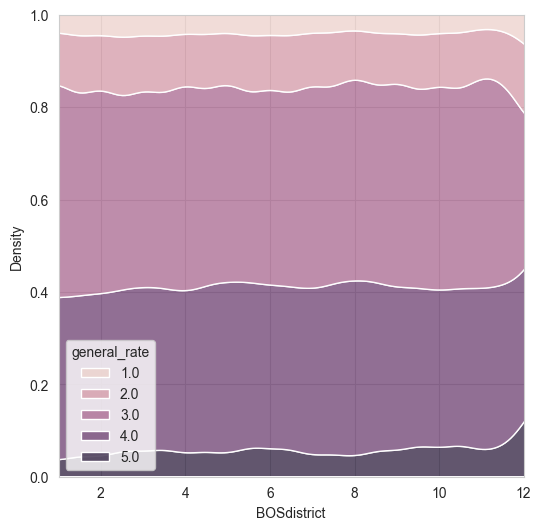

In [4]:
f, ax = plt.subplots(figsize=(6, 6))
sns.kdeplot(data=df, hue='general_rate', x='BOSdistrict', multiple="fill")
ax.set_xlim((1,12))
plt.show()

<Axes: xlabel='BOSdistrict', ylabel='general_rate'>

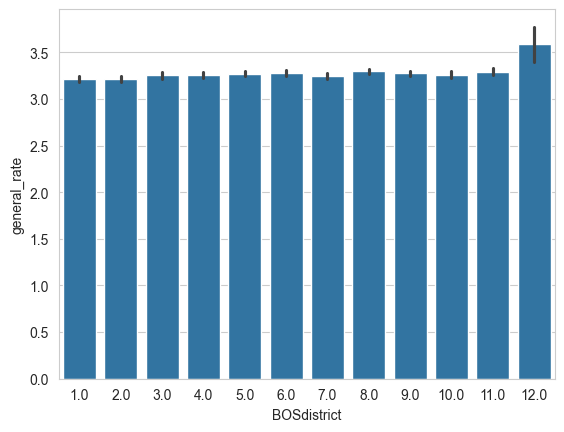

In [5]:
sns.barplot(data=df, y='general_rate', x='BOSdistrict')

We can observe that districts have relatively close weights, but district 12 has slightly better grades (five and four occur more frequently than for other districts).

## Abul-Naga Yalcin Index - code

Abul-Naga Yalcin Index is called using function `any_index`. It takes

In [6]:
# Statistics and calculations

# All districts

any_sf_eq = any_index(
    categories=list(df['general_rate'].astype(int).unique()),
    responses=df['general_rate'],
    alpha=1,
    beta=1
)

any_sf_a = any_index(
    categories=list(df['general_rate'].astype(int).unique()),
    responses=df['general_rate'],
    alpha=5,
    beta=1
)

any_sf_b = any_index(
    categories=list(df['general_rate'].astype(int).unique()),
    responses=df['general_rate'],
    alpha=1,
    beta=5
)

In [8]:
print(f'{any_sf_eq}')
print(f'{any_sf_a}')
print(f'{any_sf_b}')

index=0.6393288266537904 name='Abul Naga & Yalcin Index' n_classes=5 alpha=1.0 beta=1.0
index=0.6298184562370778 name='Abul Naga & Yalcin Index' n_classes=5 alpha=5.0 beta=1.0
index=1.1297531336775386 name='Abul Naga & Yalcin Index' n_classes=5 alpha=1.0 beta=5.0


> Something is wrong - value should not be > than 1 (see the last print) # todo - check it and define tests that catch this bug

## Summary

...

## Changelog

- 2025-12-26 : Szymon Moliński (@SimonMolinsky) : first release